In [9]:
!pip install imbalanced-learn xgboost shap -q

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [11]:
# Load churn dataset from GitHub repository, with local upload as fallback
URL = "https://raw.githubusercontent.com/yash4604j-cpu/chrun-prediction-and-dashboard/refs/heads/main/dataset.csv"

try:
    df = pd.read_csv(URL)
    print("Dataset loaded successfully from GitHub.")
except Exception:
    df = pd.read_csv("dataset.csv")
    print("Dataset loaded from local upload.")

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

Dataset loaded successfully from GitHub.
Shape: 36992 rows x 23 columns

Columns: ['age', 'gender', 'security_no', 'region_category', 'membership_category', 'joining_date', 'joined_through_referral', 'referral_id', 'preferred_offer_types', 'medium_of_operation', 'internet_option', 'last_visit_time', 'days_since_last_login', 'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet', 'used_special_discount', 'offer_application_preference', 'past_complaint', 'complaint_status', 'feedback', 'churn_risk_score']


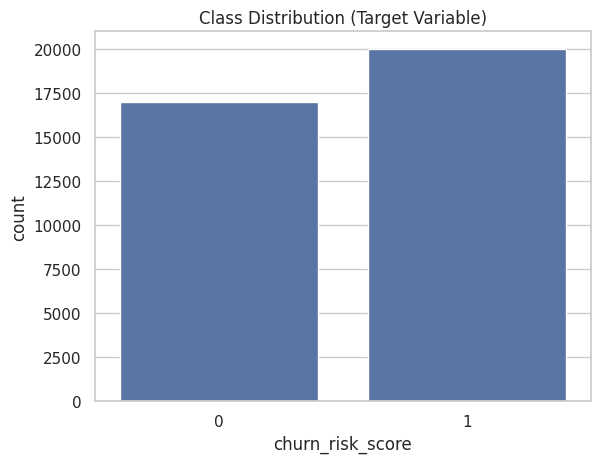

churn_risk_score
1    20012
0    16980
Name: count, dtype: int64


In [12]:
sns.countplot(x='churn_risk_score', data=df)
plt.title("Class Distribution (Target Variable)")
plt.show()

print(df['churn_risk_score'].value_counts())

In [13]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nAnomaly counts:")
print("  days_since_last_login (-999 count):", (df['days_since_last_login'] == -999).sum())
print("  avg_frequency_login_days ('Error' count):", (df['avg_frequency_login_days'] == 'Error').sum())
print("  joined_through_referral ('?' count):", (df['joined_through_referral'] == '?').sum())
print("  medium_of_operation ('?' count):", (df['medium_of_operation'] == '?').sum())

Missing values per column:
region_category          5428
preferred_offer_types     288
points_in_wallet         3443
dtype: int64

Anomaly counts:
  days_since_last_login (-999 count): 1999
  avg_frequency_login_days ('Error' count): 3522
  joined_through_referral ('?' count): 5438
  medium_of_operation ('?' count): 5393


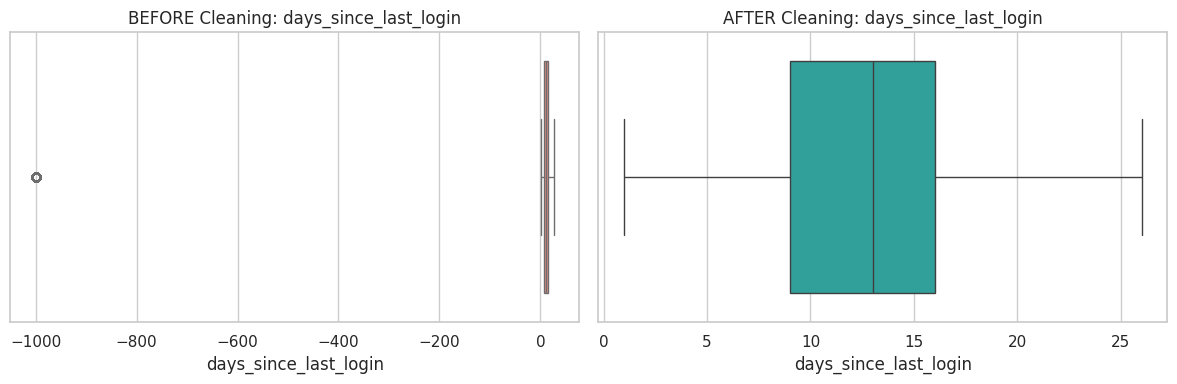

In [14]:
plt.figure(figsize=(12, 4))

# BEFORE
plt.subplot(1, 2, 1)
sns.boxplot(x=df['days_since_last_login'], color='salmon')
plt.title("BEFORE Cleaning: days_since_last_login")

# CLEANING
df['no_login_flag'] = (df['days_since_last_login'] == -999).astype(int)
valid_login_median = df[df['days_since_last_login'] != -999]['days_since_last_login'].median()
df['days_since_last_login'] = df['days_since_last_login'].replace(-999, valid_login_median)

# AFTER
plt.subplot(1, 2, 2)
sns.boxplot(x=df['days_since_last_login'], color='lightseagreen')
plt.title("AFTER Cleaning: days_since_last_login")

plt.tight_layout()
plt.show()

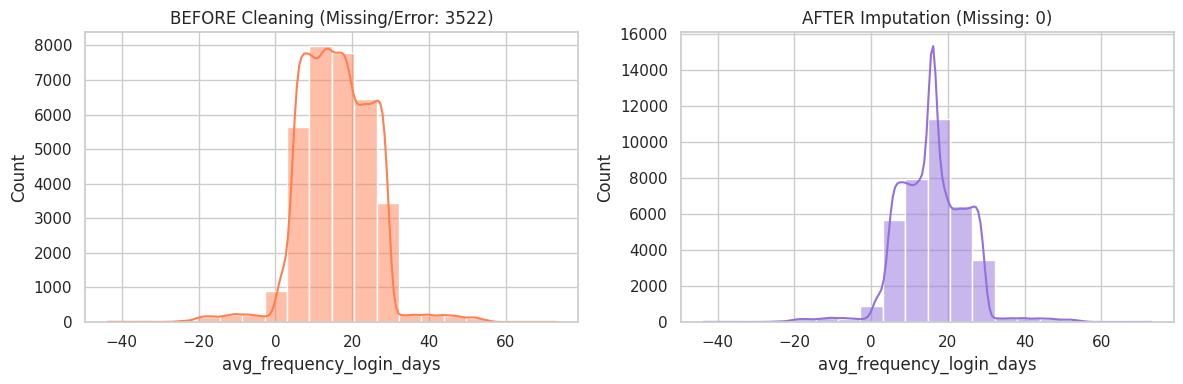

In [15]:
plt.figure(figsize=(12, 4))

# BEFORE
raw_series = pd.to_numeric(df['avg_frequency_login_days'], errors='coerce')

plt.subplot(1, 2, 1)
sns.histplot(raw_series.dropna(), bins=20, color='coral', kde=True)
plt.title(f"BEFORE Cleaning (Missing/Error: {raw_series.isnull().sum()})")

# CLEANING
df['avg_frequency_login_days'] = raw_series
df['missing_frequency_flag'] = df['avg_frequency_login_days'].isnull().astype(int)
median_freq = df['avg_frequency_login_days'].median()
df['avg_frequency_login_days'] = df['avg_frequency_login_days'].fillna(median_freq)

# AFTER
plt.subplot(1, 2, 2)
sns.histplot(df['avg_frequency_login_days'], bins=20, color='mediumpurple', kde=True)
plt.title(f"AFTER Imputation (Missing: {df['avg_frequency_login_days'].isnull().sum()})")

plt.tight_layout()
plt.show()

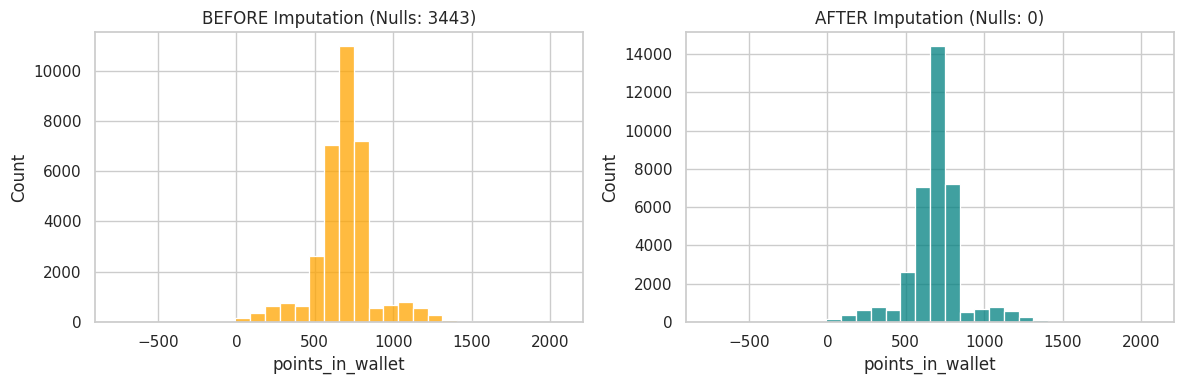

In [16]:
plt.figure(figsize=(12, 4))

# BEFORE
plt.subplot(1, 2, 1)
sns.histplot(df['points_in_wallet'].dropna(), bins=30, color='orange')
plt.title(f"BEFORE Imputation (Nulls: {df['points_in_wallet'].isnull().sum()})")

# CLEANING
df['missing_points_flag'] = df['points_in_wallet'].isnull().astype(int)
median_points = df['points_in_wallet'].median()
df['points_in_wallet'] = df['points_in_wallet'].fillna(median_points)

# AFTER
plt.subplot(1, 2, 2)
sns.histplot(df['points_in_wallet'], bins=30, color='teal')
plt.title(f"AFTER Imputation (Nulls: {df['points_in_wallet'].isnull().sum()})")

plt.tight_layout()
plt.show()

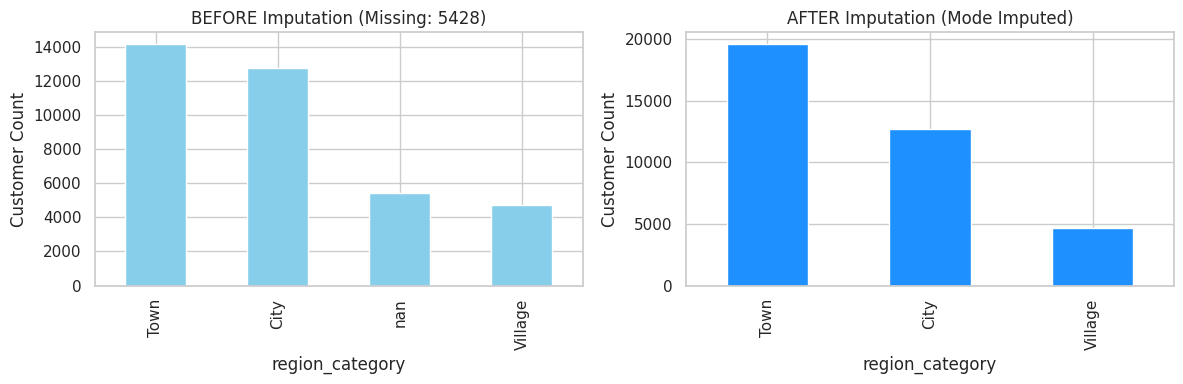

In [17]:
plt.figure(figsize=(12, 4))

# BEFORE
plt.subplot(1, 2, 1)
df['region_category'].value_counts(dropna=False).plot(kind='bar', color='skyblue')
plt.title(f"BEFORE Imputation (Missing: {df['region_category'].isnull().sum()})")
plt.ylabel("Customer Count")

# CLEANING
df['missing_region_flag'] = df['region_category'].isnull().astype(int)
mode_region = df['region_category'].mode()[0]
df['region_category'] = df['region_category'].fillna(mode_region)

# AFTER
plt.subplot(1, 2, 2)
df['region_category'].value_counts().plot(kind='bar', color='dodgerblue')
plt.title("AFTER Imputation (Mode Imputed)")
plt.ylabel("Customer Count")

plt.tight_layout()
plt.show()

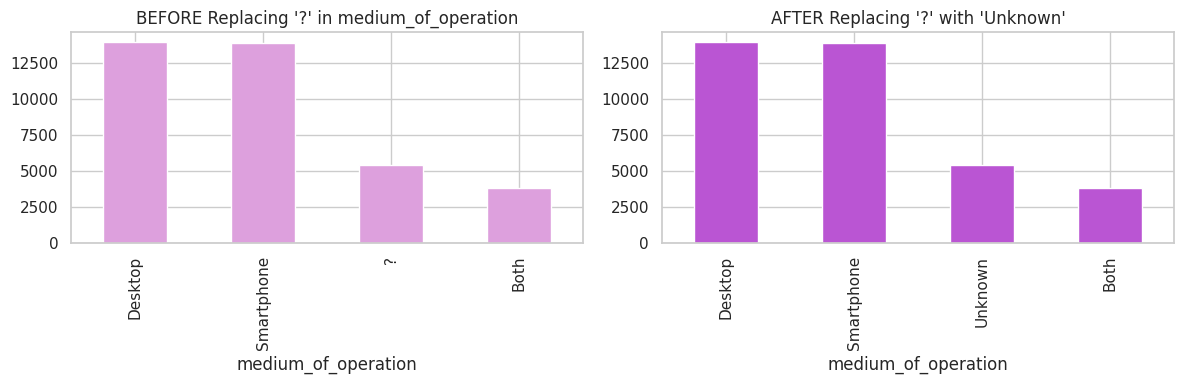

In [18]:
plt.figure(figsize=(12, 4))

# BEFORE
plt.subplot(1, 2, 1)
df['medium_of_operation'].value_counts().plot(kind='bar', color='plum')
plt.title("BEFORE Replacing '?' in medium_of_operation")

# CLEANING
df['joined_through_referral'] = df['joined_through_referral'].replace('?', 'Unknown')
df['medium_of_operation'] = df['medium_of_operation'].replace('?', 'Unknown')
preferred_offer_mode = df['preferred_offer_types'].mode()[0]
df['preferred_offer_types'] = df['preferred_offer_types'].fillna(preferred_offer_mode)

# AFTER
plt.subplot(1, 2, 2)
df['medium_of_operation'].value_counts().plot(kind='bar', color='mediumorchid')
plt.title("AFTER Replacing '?' with 'Unknown'")

plt.tight_layout()
plt.show()

In [19]:
# Keep original gender/region for the fairness audit later, before they get encoded away
fairness_cols = df[['gender', 'region_category']].copy()

# tenure in months
joining_dt = pd.to_datetime(df['joining_date'], format='%d-%m-%Y', errors='coerce')
max_date = joining_dt.max()
df['tenure_months'] = ((max_date - joining_dt).dt.days / 30.4).fillna(0)
df = df.drop(columns=['joining_date'])

# visit hour
df['visit_hour'] = pd.to_datetime(df['last_visit_time'], format='%H:%M:%S', errors='coerce').dt.hour.fillna(12)
df = df.drop(columns=['last_visit_time'])

print("tenure_months and visit_hour created.")

tenure_months and visit_hour created.


In [20]:
feedback_map = {
    'Poor Product Quality': -2, 'Poor Customer Service': -2,
    'Too many ads': -1, 'Poor Website': -1,
    'No reason specified': 0, 'Reasonable Price': 1,
    'User Friendly Website': 1, 'Products always in Stock': 2,
    'Quality Customer Care': 2
}
df['feedback_score'] = df['feedback'].map(feedback_map).fillna(0)
df = df.drop(columns=['feedback'])

print("feedback_score created.")
df['feedback_score'].value_counts()

feedback_score created.


,count
feedback_score,
-2,12602
-1,12550
0,6290
1,2808
2,2742


In [21]:
unresolved = ['Unsolved', 'No Information Available']
df['active_complaint'] = ((df['past_complaint'] == 'Yes') & (df['complaint_status'].isin(unresolved))).astype(int)
df = df.drop(columns=['past_complaint', 'complaint_status'])

print("active_complaint created.")
df['active_complaint'].value_counts()

active_complaint created.


,count
active_complaint,
0,27798
1,9194


In [22]:
membership_map = {
    'No Membership': 0, 'Basic Membership': 1, 'Silver Membership': 2,
    'Gold Membership': 3, 'Premium Membership': 4, 'Platinum Membership': 5
}
df['membership_score'] = df['membership_category'].map(membership_map).fillna(0)
df = df.drop(columns=['membership_category'])

print("membership_score created.")
df['membership_score'].value_counts()

membership_score created.


,count
membership_score,
1,7724
0,7692
3,6795
2,5988
4,4455
5,4338


In [23]:
for col in ['used_special_discount', 'offer_application_preference', 'joined_through_referral']:
    df[col] = (df[col] == 'Yes').astype(int)

df = df.drop(columns=['security_no', 'referral_id'], errors='ignore')

print("Feature engineering done! Final shape:", df.shape)

Feature engineering done! Final shape: (36992, 24)


In [24]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['churn_risk_score'])
y = df['churn_risk_score']

categorical_cols = ['gender', 'region_category', 'preferred_offer_types', 'medium_of_operation', 'internet_option']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.20, random_state=42, stratify=y
)

print("X_train size:", X_train.shape)
print("X_test size:", X_test.shape)

X_train size: (29593, 29)
X_test size: (7399, 29)


In [25]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['age', 'days_since_last_login', 'avg_time_spent',
                'avg_transaction_value', 'avg_frequency_login_days',
                'points_in_wallet', 'tenure_months', 'visit_hour']

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Scaling done!")

Scaling done!


MODELS - WITHOUT SMOTE

1. LOGISTIC REGRESSION

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

lr_auc = roc_auc_score(y_test, y_prob_lr)
lr_prec = precision_score(y_test, y_pred_lr)
lr_rec = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("--- Logistic Regression (Without SMOTE) ---")
print("AUC-ROC:", round(lr_auc, 4))
print("Precision:", round(lr_prec, 4))
print("Recall:", round(lr_rec, 4))
print("F1-Score:", round(lr_f1, 4))

--- Logistic Regression (Without SMOTE) ---
AUC-ROC: 0.944
Precision: 0.8592
Recall: 0.8688
F1-Score: 0.864


2. RANDOM FOREST

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, y_prob_rf)
rf_prec = precision_score(y_test, y_pred_rf)
rf_rec = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("--- Random Forest (Without SMOTE) ---")
print("AUC-ROC:", round(rf_auc, 4))
print("Precision:", round(rf_prec, 4))
print("Recall:", round(rf_rec, 4))
print("F1-Score:", round(rf_f1, 4))

--- Random Forest (Without SMOTE) ---
AUC-ROC: 0.9747
Precision: 0.9365
Recall: 0.9363
F1-Score: 0.9364


3. XGBOOST

In [28]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

xgb_auc = roc_auc_score(y_test, y_prob_xgb)
xgb_prec = precision_score(y_test, y_pred_xgb)
xgb_rec = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print("--- XGBoost (Without SMOTE) ---")
print("AUC-ROC:", round(xgb_auc, 4))
print("Precision:", round(xgb_prec, 4))
print("Recall:", round(xgb_rec, 4))
print("F1-Score:", round(xgb_f1, 4))

--- XGBoost (Without SMOTE) ---
AUC-ROC: 0.975
Precision: 0.9384
Recall: 0.943
F1-Score: 0.9407


CONFUSION MATRICES OF ALL THREE MODELS[WITHOUT SMOTE]

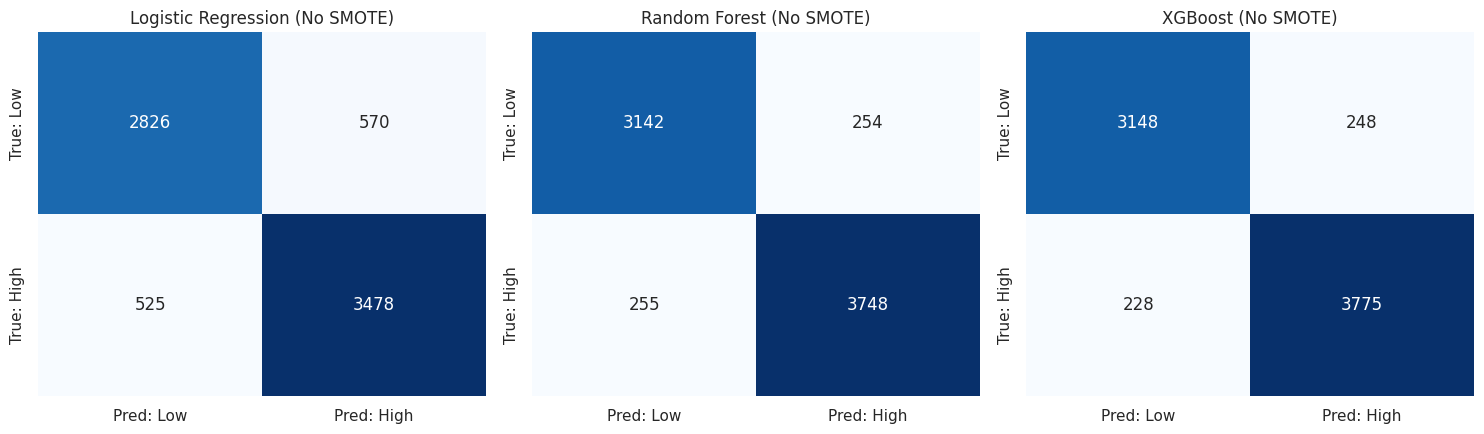

In [29]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (title, pred) in zip(axes, [
    ("Logistic Regression (No SMOTE)", y_pred_lr),
    ("Random Forest (No SMOTE)", y_pred_rf),
    ("XGBoost (No SMOTE)", y_pred_xgb),
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Pred: Low', 'Pred: High'], yticklabels=['True: Low', 'True: High'])
    ax.set_title(title)
plt.tight_layout()
plt.show()

APPLYING SMOTE

Original training target distribution:
 churn_risk_score
1    16009
0    13584
Name: count, dtype: int64

Resampled training target distribution:
 churn_risk_score
0    16009
1    16009
Name: count, dtype: int64


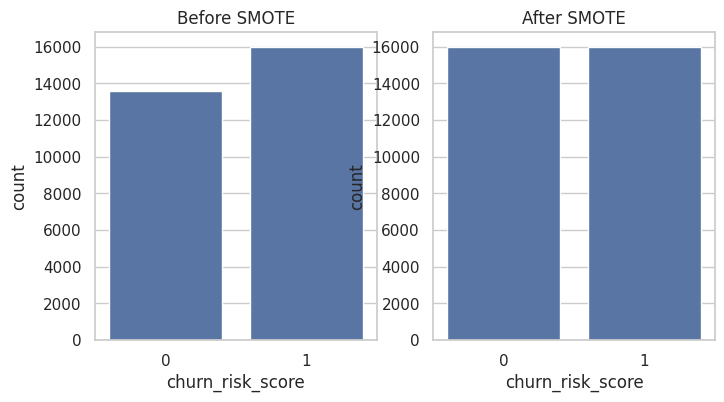

In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Original training target distribution:\n", y_train.value_counts())
print("\nResampled training target distribution:\n", pd.Series(y_train_sm).value_counts())

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title("Before SMOTE")

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_sm)
plt.title("After SMOTE")
plt.show()

MODELS - WITH SMOTE

1. LOGISTIC REGRESSION

In [31]:
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_sm, y_train_sm)

y_pred_lr_sm = lr_smote.predict(X_test)
y_prob_lr_sm = lr_smote.predict_proba(X_test)[:, 1]

lr_sm_auc = roc_auc_score(y_test, y_prob_lr_sm)
lr_sm_prec = precision_score(y_test, y_pred_lr_sm)
lr_sm_rec = recall_score(y_test, y_pred_lr_sm)
lr_sm_f1 = f1_score(y_test, y_pred_lr_sm)

print("--- Logistic Regression (With SMOTE) ---")
print("AUC-ROC:", round(lr_sm_auc, 4))
print("Precision:", round(lr_sm_prec, 4))
print("Recall:", round(lr_sm_rec, 4))
print("F1-Score:", round(lr_sm_f1, 4))

--- Logistic Regression (With SMOTE) ---
AUC-ROC: 0.9431
Precision: 0.8677
Recall: 0.8601
F1-Score: 0.8639


2. RANDOM FOREST

In [32]:
rf_smote = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
rf_smote.fit(X_train_sm, y_train_sm)

y_pred_rf_sm = rf_smote.predict(X_test)
y_prob_rf_sm = rf_smote.predict_proba(X_test)[:, 1]

rf_sm_auc = roc_auc_score(y_test, y_prob_rf_sm)
rf_sm_prec = precision_score(y_test, y_pred_rf_sm)
rf_sm_rec = recall_score(y_test, y_pred_rf_sm)
rf_sm_f1 = f1_score(y_test, y_pred_rf_sm)

print("--- Random Forest (With SMOTE) ---")
print("AUC-ROC:", round(rf_sm_auc, 4))
print("Precision:", round(rf_sm_prec, 4))
print("Recall:", round(rf_sm_rec, 4))
print("F1-Score:", round(rf_sm_f1, 4))

--- Random Forest (With SMOTE) ---
AUC-ROC: 0.9745
Precision: 0.9446
Recall: 0.9278
F1-Score: 0.9361


3. XGBOOST

In [33]:
xgb_smote = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_smote.fit(X_train_sm, y_train_sm)

y_pred_xgb_sm = xgb_smote.predict(X_test)
y_prob_xgb_sm = xgb_smote.predict_proba(X_test)[:, 1]

xgb_sm_auc = roc_auc_score(y_test, y_prob_xgb_sm)
xgb_sm_prec = precision_score(y_test, y_pred_xgb_sm)
xgb_sm_rec = recall_score(y_test, y_pred_xgb_sm)
xgb_sm_f1 = f1_score(y_test, y_pred_xgb_sm)

print("--- XGBoost (With SMOTE) ---")
print("AUC-ROC:", round(xgb_sm_auc, 4))
print("Precision:", round(xgb_sm_prec, 4))
print("Recall:", round(xgb_sm_rec, 4))
print("F1-Score:", round(xgb_sm_f1, 4))

--- XGBoost (With SMOTE) ---
AUC-ROC: 0.9755
Precision: 0.9447
Recall: 0.9345
F1-Score: 0.9396


CONFUSION MATRICES OF ALL THREE MODELS[WITH SMOTE]

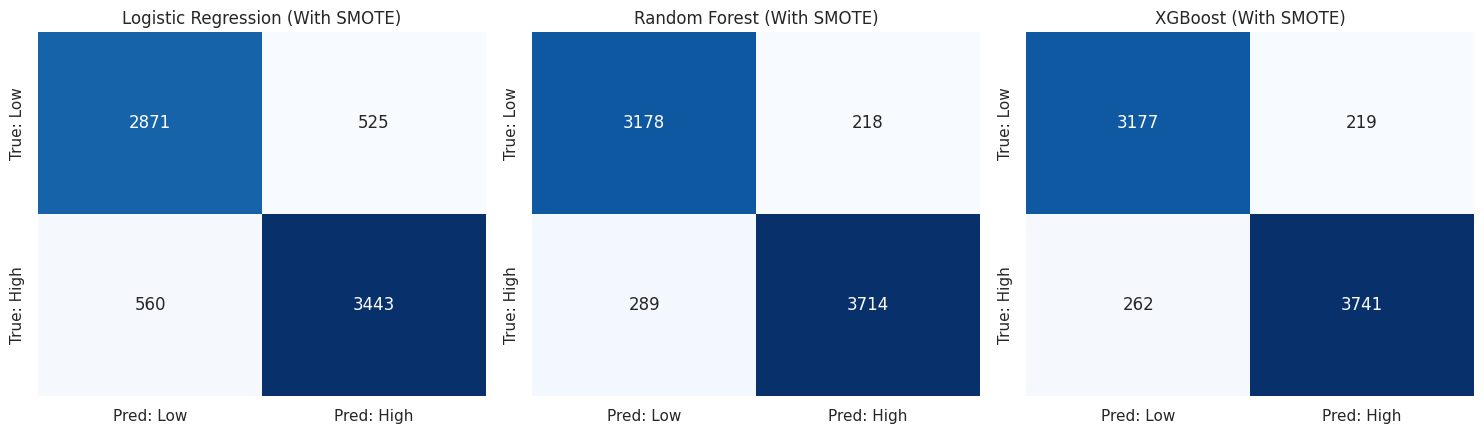

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (title, pred) in zip(axes, [
    ("Logistic Regression (With SMOTE)", y_pred_lr_sm),
    ("Random Forest (With SMOTE)", y_pred_rf_sm),
    ("XGBoost (With SMOTE)", y_pred_xgb_sm),
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Pred: Low', 'Pred: High'], yticklabels=['True: Low', 'True: High'])
    ax.set_title(title)
plt.tight_layout()
plt.show()

COMPARISON OF MODELS

1. SUMMARY - COMPARISON TABLE

In [35]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Logistic Regression', 'Random Forest', 'Random Forest', 'XGBoost', 'XGBoost'],
    'SMOTE': ['No', 'Yes', 'No', 'Yes', 'No', 'Yes'],
    'AUC-ROC': [lr_auc, lr_sm_auc, rf_auc, rf_sm_auc, xgb_auc, xgb_sm_auc],
    'Precision': [lr_prec, lr_sm_prec, rf_prec, rf_sm_prec, xgb_prec, xgb_sm_prec],
    'Recall': [lr_rec, lr_sm_rec, rf_rec, rf_sm_rec, xgb_rec, xgb_sm_rec],
    'F1-Score': [lr_f1, lr_sm_f1, rf_f1, rf_sm_f1, xgb_f1, xgb_sm_f1]
})
comparison_df = comparison_df.round(4)
comparison_df

,Model,SMOTE,AUC-ROC,Precision,Recall,F1-Score
0,Logistic Regression,No,0.9440,0.8592,0.8688,0.8640
1,Logistic Regression,Yes,0.9431,0.8677,0.8601,0.8639
2,Random Forest,No,0.9747,0.9365,0.9363,0.9364
3,Random Forest,Yes,0.9745,0.9446,0.9278,0.9361
4,XGBoost,No,0.9750,0.9384,0.9430,0.9407
5,XGBoost,Yes,0.9755,0.9447,0.9345,0.9396


AUC - ROC COMPARISON CHART

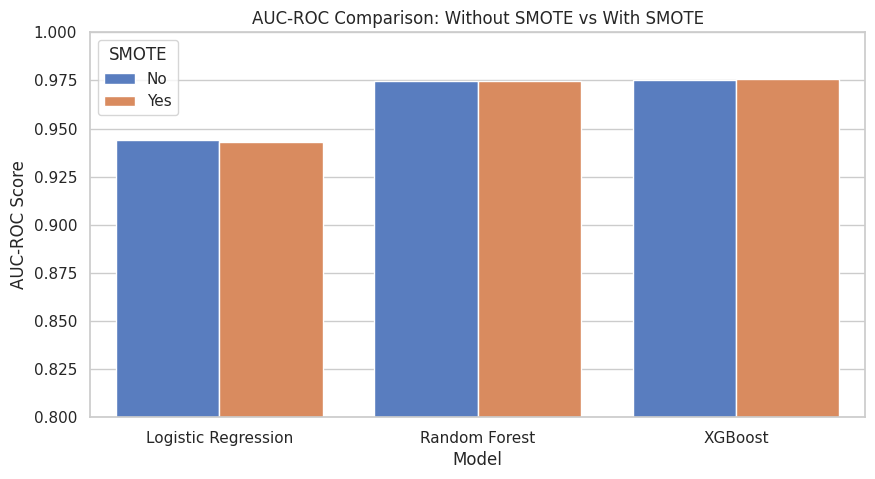

In [36]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='AUC-ROC', hue='SMOTE', data=comparison_df, palette='muted')
plt.title("AUC-ROC Comparison: Without SMOTE vs With SMOTE")
plt.ylim(0.8, 1.0)
plt.ylabel("AUC-ROC Score")
plt.show()

3. ROC CURVES

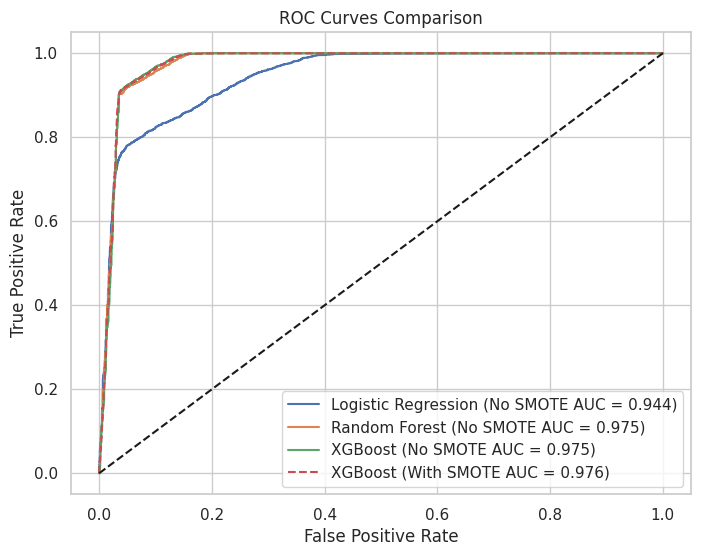

In [37]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_xgb_sm, tpr_xgb_sm, _ = roc_curve(y_test, y_prob_xgb_sm)

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (No SMOTE AUC = {lr_auc:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (No SMOTE AUC = {rf_auc:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (No SMOTE AUC = {xgb_auc:.3f})")
plt.plot(fpr_xgb_sm, tpr_xgb_sm, label=f"XGBoost (With SMOTE AUC = {xgb_sm_auc:.3f})", linestyle='--')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()

SHAP INTERPRETABILITY - CHAMPION MODEL ONLY

In [38]:
import shap

explainer = shap.TreeExplainer(xgb_smote)
sample_idx = np.random.RandomState(42).choice(X_test.index, size=min(1000, len(X_test)), replace=False)
X_shap_sample = X_test.loc[sample_idx]
shap_values = explainer.shap_values(X_shap_sample)

print("SHAP values computed for", len(X_shap_sample), "test customers.")

SHAP values computed for 1000 test customers.


SHAP BEESWARM PLOT

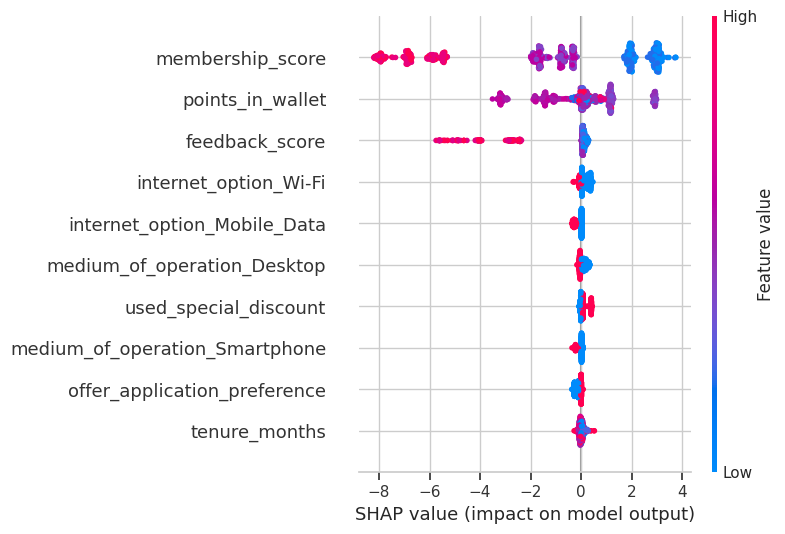

In [39]:
shap.summary_plot(shap_values, X_shap_sample, max_display=10)

SHAP GOBAL IMPORTANCE BAR CHART

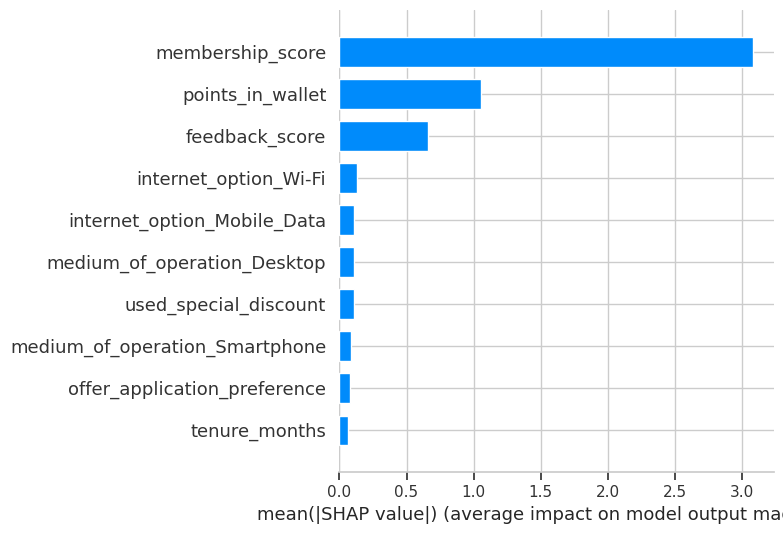

In [40]:
shap.summary_plot(shap_values, X_shap_sample, plot_type='bar', max_display=10)

FAIRNESS METRICS BY GENDER AND REGION

In [41]:
test_fair = fairness_cols.loc[idx_test].copy()
test_fair['y_true'] = y_test.values
test_fair['y_pred'] = y_pred_xgb_sm

def subgroup_metrics(frame, group_col):
    rows = []
    for g, sub in frame.groupby(group_col):
        rows.append({
            'subgroup': str(g), 'n': len(sub),
            'precision': round(precision_score(sub['y_true'], sub['y_pred'], zero_division=0), 4),
            'recall': round(recall_score(sub['y_true'], sub['y_pred'], zero_division=0), 4),
            'f1': round(f1_score(sub['y_true'], sub['y_pred'], zero_division=0), 4),
        })
    return pd.DataFrame(rows)

gender_fairness = subgroup_metrics(test_fair, 'gender')
region_fairness = subgroup_metrics(test_fair, 'region_category')

print("Fairness by gender:")
display(gender_fairness)
print("\nFairness by region:")
display(region_fairness)

Fairness by gender:


,subgroup,n,precision,recall,f1
0,F,3729,0.9455,0.9353,0.9403
1,M,3664,0.9438,0.9337,0.9387
2,Unknown,6,1.0000,1.0000,1.0000



Fairness by region:


,subgroup,n,precision,recall,f1
0,City,2585,0.9447,0.9347,0.9397
1,Town,3921,0.9458,0.9318,0.9388
2,Village,893,0.9392,0.9477,0.9434


FAIRNESS CHART

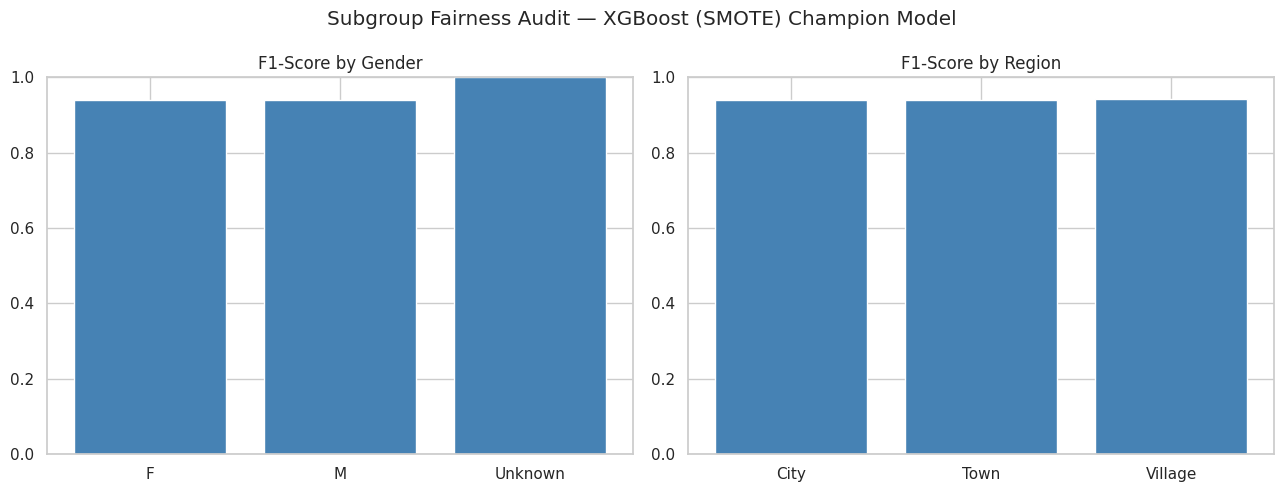

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(gender_fairness['subgroup'], gender_fairness['f1'], color='steelblue')
axes[0].set_title("F1-Score by Gender")
axes[0].set_ylim(0, 1)

axes[1].bar(region_fairness['subgroup'], region_fairness['f1'], color='steelblue')
axes[1].set_title("F1-Score by Region")
axes[1].set_ylim(0, 1)

plt.suptitle("Subgroup Fairness Audit — XGBoost (SMOTE) Champion Model")
plt.tight_layout()
plt.show()

EXPORTING PIPELINE FOR THE DASHBOARD PROTOTYPE

In [43]:
import joblib

pipeline_export = {
    'model_name': 'XGBoost (With SMOTE)',
    'model': xgb_smote,
    'scaler': scaler,
    'feature_cols': X.columns.tolist(),
    'numeric_cols': numeric_cols,
    'categorical_cols': ['gender', 'region_category', 'preferred_offer_types', 'medium_of_operation', 'internet_option'],
    'preproc_meta': {
        'median_points': float(median_points),
        'mode_region': mode_region,
        'max_date': str(max_date),
        'median_login_days': float(median_freq),
        'valid_login_median': float(valid_login_median),
        'preferred_offer_mode': preferred_offer_mode,
        'feedback_map': feedback_map,
        'membership_map': membership_map,
        'unresolved_complaint_statuses': unresolved,
    }
}
joblib.dump(pipeline_export, "churn_pipeline.joblib")
print("Saved model pipeline to churn_pipeline.joblib successfully!")

files.download("churn_pipeline.joblib")

Saved model pipeline to churn_pipeline.joblib successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>